<a href="https://colab.research.google.com/github/HamiltonLROliveira/ciencia_dados_puc_rj/blob/main/mvp_pucrj_engenharia_dados_hamilton_oliveira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## MVP da Disciplina de Engenharia de Dados da Pós-graducação em Ciência de Dados da PUC-Rio
###Aluno: Hamilton Luiz Rodrigues de Oliveira

O trabalho está organizado conforme descrito a seguir:

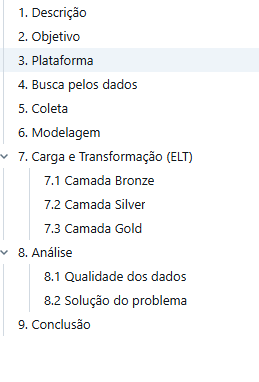


##1. Descrição
Este trabalho consiste na construção de um pipeline de dados utilizando tecnologias na nuvem. O pipeline envolveu a busca, coleta, modelagem, carga e análise dos dados.

## 2. Objetivo
Este MVP tem como objetivo viabilizar a realização de análises na folha de pagamento dos servidores públicos civis federais do Poder Executivo Federal. Sendo assim, o trabalho consiste em permitir que as seguintes perguntas sejam respondidas:

1. Qual a variação, percentual e monetária, de gastos da despesa com folha de pagamento do governo federal no período analisado?

2.	Quais os dez órgãos com maiores valores de gastos com folha de pagamento, no período analisado?

3.	Quais os dez órgãos com maiores gastos per capta, no período analisado?

4.	Como está distribuída a remuneração dos servidores? Qual a média, desvio padrão e valores mínimos e máximos?

5. Quais os órgãos com maiores somas de gastos com folha de pagamento, no período analisado, por estado e por região?

6.	Quais órgãos possuem maiores gastos per capta, no período analisado, por estado e por região?

##3. Plataforma
O trabalho foi desenvolvido no Databricks, disponibilizada pela empresa de mesmo nome, que vem a ser uma plataforma de análise de dados que permite criar, implantar, compartilhar e gerenciar soluções de IA e análises. A empresa disponibiliza a versão Databricks Community Edition livre de custos, motivo pelo qual foi escolhida para a implantação da solução.

##4. Busca pelos dados

Para a realização deste trabalho foram utilizadas bases de dados da remuneração dos servidores públicos federal do Governo Federal, disponíveis no Portal da Transparência do Governo Federal (https://portaldatransparencia.gov.br/). Na seção Dados Abertos (https://portaldatransparencia.gov.br/download-de-dados) é possível realizar o download de diversas bases de dados sobre as finanças do Governo Federal, como por exemplo, Cartão de Pagamento, Convênios, Imóveis Funcionais, Orçamento Público, Servidores Públicos entre outros.
Uma análise nos dados disponíveis no site mostrou que para responder as perguntas propostas na Seção Objetivo deste trabalho, bastavam as bases de dados disponiveis na seção Servidores Públicos do site.

Os dados dos servidores públicos federais são divididos em servidores ativos, inativos e pensionistas. Por questões de economia, este trabalho aborda apenas despesas referentes aos servidores ativos, considerando que é a maior fatia de gastos com folha de pagamento. Os dados dos servidores ativos são ainda divididos em: Honorários_Jetons, Militares, Servidores do Banco Central e Servidores SIAPE. Este último, SIAPE, vem a ser o Sistema Integrado de Administração de Recursos Humanos, uma plataforma online que centraliza a gestão de pagamentos de servidores públicos federais. Optou, novamente, por questões de economia operacional, utilizar os dados apenas do SIAPE, o que não trás prejuízos para as conclusão tendo em vista que o referido Sistema concentra todos os órgãos da Administração Pública Federal, exceto como dito anteriormente, militares e servidores do Banco Central do Brasil.

##5. Coleta

Considerando que os dados estão dispníveis no Portal da Transparência, o trabalho de coleta consistiu na realização de download dos mesmos para posterior inserção na Plataforma Databricks. Os dados estão disponíveis por ano e por mês. Os dados para download estão disponíveis a partir do ano de 2013, no entanto, a estrutura de dados da forma como está permanece a mesma nos últimos 5 anos. Novamente por questão de economia operacional, optou-se por utilizar os dados dos anos de 2023 e 2024. Considerando que a estrutura de dados é a mesma desde 2020, não haveria qualquer impedimento ou obstáculo para que fossem realizados o download dos dados dos anos de 2020, 2021 e 2022. Conforme será mostrado ao longo do trabalho, o pipeline foi escrito para não fazer restrição ao ano da base de dados, portanto, para que se obtenha informaçoes sobre os anos de 2020, 2021 e 2022 basta que se faça o download dos dados dos referidos anos e execute o pipeline novamente. Os dados foram inserido na Plataforma Databricks por meio do procedimento de upload.

Sendo assim, foram baixadas as tabelas de cadastro e remuneração mês a mês dos anos de 2023 e 2024. Ao todo foram baixados 46 arquivos, 23 de cadastro e 23 de remuneração. A estrutura dos arquvivos, dicionário de dados, será apresentado na próxima Seção.

##6. Modelagem

Conforme explicado anteriormente, os dados estão organizados na forma de arquivos texto, csv, sendo um arquivo com dados de cadastro e outro arquivo com dados da remneração. No Portal da Transparência estão disponíveis juntamento com os dados, um dicionário de dados de cada arquivo conforme apresentado a seguir:

Dicionário de dados da tabela Cadastro

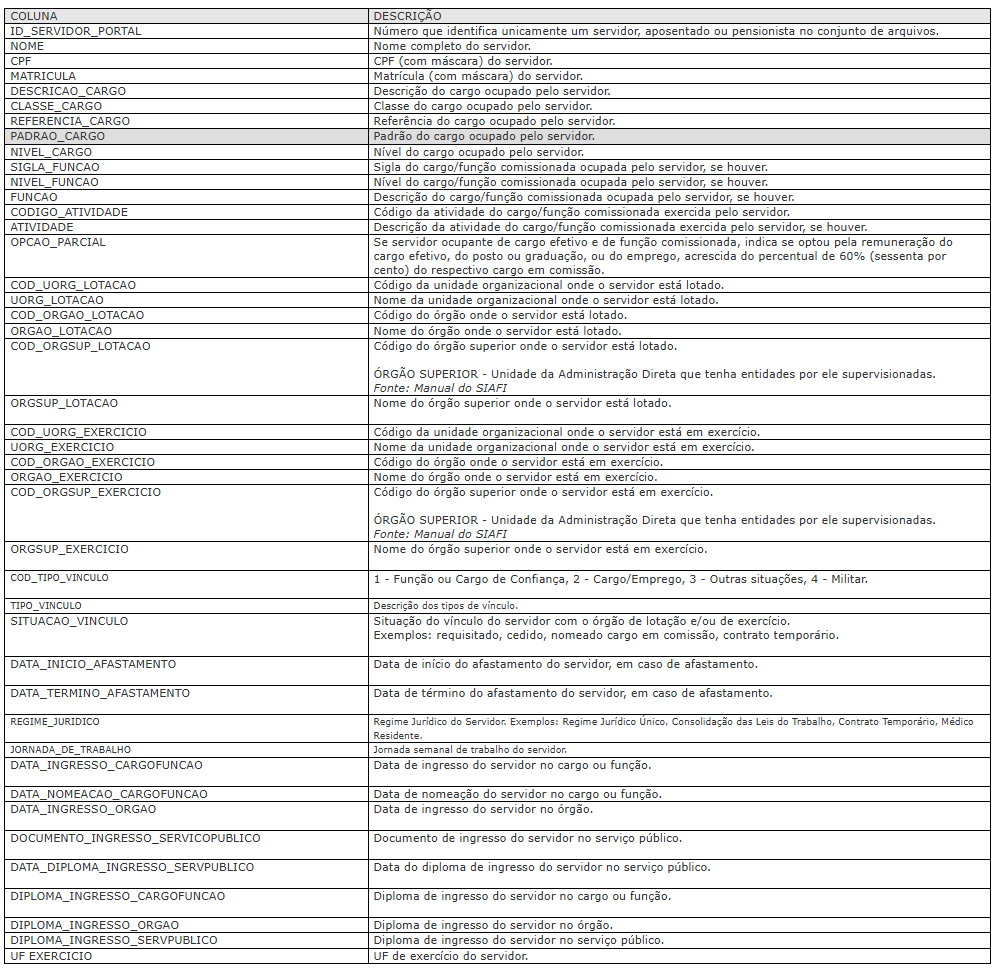

Analisando os dados disponíveis, conclui-se que é possível responder grande parte das questões propostas na Seção Objetivo. Para que se responda as perguntas, no entanto, serão necessárias transformações nos dados obtidos. Por questões de desempenho e facilidade para a elaboração das consultas optou-se pela consutrução de uma tabela flat, tabela única, agregando os dados de cadastro e remuneração. Tais considerações serão melhor apresentadas na Seção Análise, descrita no final do trabalho.


Dicionário de Dados da Tabela Remuneração

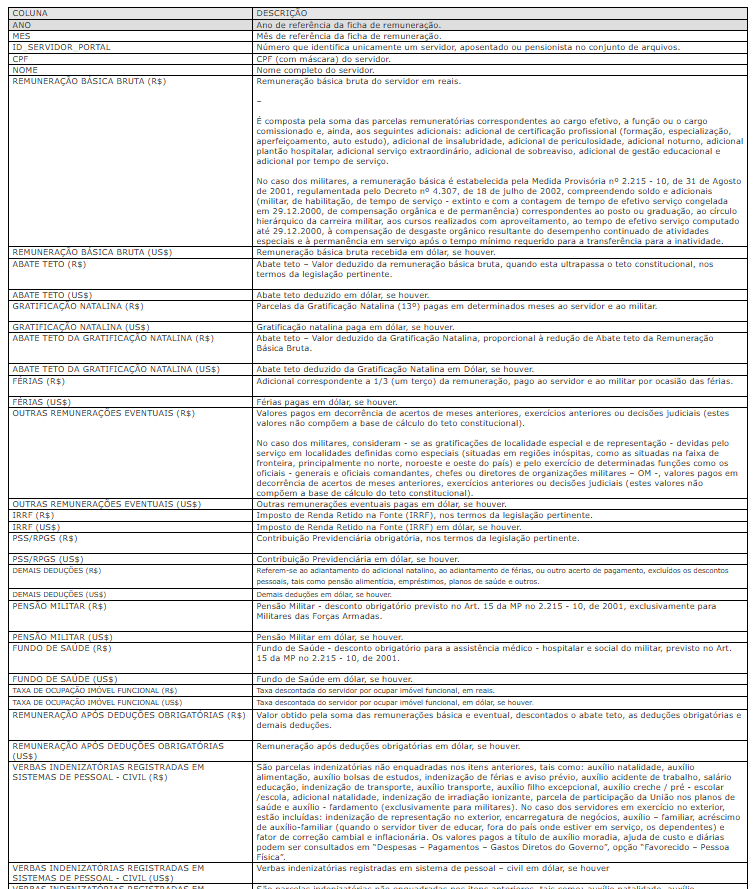

Segue um Diagrama de Entidade Relacionamentos com as tuas tabelas:


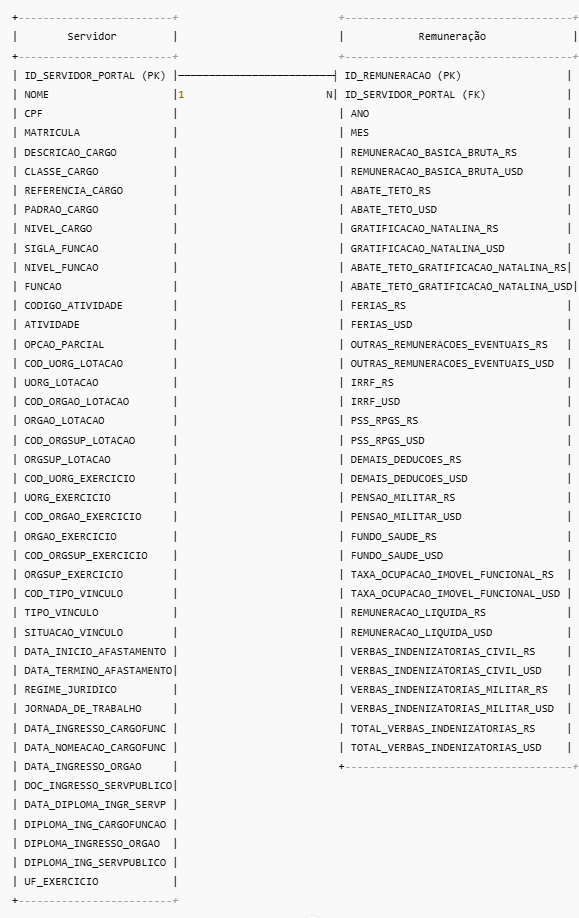


##7. Carga e Transformação (ELT)

Nesta Seção serão apresentados os procedimentos para a realização da carga dos dados, bem com suas respectivas transformações, na Plataforma Databricks. Os procedimentos seguiram o padrão proposto pela Arquitetura Medalhão. Tal arquitetura, refere-se ao design de dados usado para organizar logicamente os dados do lakehouse, que visa melhorar de forma incremental e progressiva a estrutura e a qualidade dos dados à medida que fluem pelas três camadas da arquitetura (tabelas Bronze ⇒ Prata ⇒ Ouro). A arquitetura medalhão também é conhecida como arquitetura “multi-hop”, conforme descrito em https://www.databricks.com/br/glossary/medallion-architecture.

Desta forma, na camada Bronze os dados são mantidos intactos, exatamente da forma como foram inseridos na Plataforma. Na camada Silver, foram realizados ajustes e remoção dos dados que não interessavam na solução das perguntas propostas. A seguir são descritos os procedimentos de cada seção com as respectivas apresentações dos scripts desenvolvidos.


###7.1 Camada Bronze

Conforme explicado anteriormente, nesta camada os dados são mantidos exatamente da mesma forma que foram inseridos na Plataforma sem que fosse feito qualquer ajuste. O script a seguir lista os 46 arquivos em csv no diretório '/FileStore/tables/' onde o Databricks armazena os dados que são feitos os uploads. Considerando ser este um diretório de passagem de arquivos, não foi contemplado em qualquer uma das camadas da Arquitetura Medalhão.
Os dados serão carregados para posterior transformação, ou seja, será utilizada a estratégia de ELT (Extração, Carga e Transformação), de modo que todas as transformações serão realizadas no ambiente Databricks.

In [ ]:
#Importa regexp_replace que será utilizada para ajustes dos dados
from pyspark.sql.functions import regexp_replace
#Importa SparkSession
from pyspark.sql import SparkSession

In [ ]:
#Mostra os arquivos no diretório onde são feitos os uploads para o sistema de arquivos do Databricks
display(dbutils.fs.ls("/FileStore/tables/"))

path,name,size,modificationTime
dbfs:/FileStore/tables/202301_Cadastro.csv,202301_Cadastro.csv,420916189,1743272634000
dbfs:/FileStore/tables/202301_Remuneracao.csv,202301_Remuneracao.csv,164867176,1743272637000
dbfs:/FileStore/tables/202302_Cadastro.csv,202302_Cadastro.csv,419073971,1743272757000
dbfs:/FileStore/tables/202302_Remuneracao.csv,202302_Remuneracao.csv,163383761,1743272675000
dbfs:/FileStore/tables/202303_Cadastro.csv,202303_Cadastro.csv,416520762,1743272801000
dbfs:/FileStore/tables/202303_Remuneracao.csv,202303_Remuneracao.csv,163127083,1743272803000
dbfs:/FileStore/tables/202304_Cadastro.csv,202304_Cadastro.csv,416157017,1743272919000
dbfs:/FileStore/tables/202304_Remuneracao.csv,202304_Remuneracao.csv,162726763,1743272846000
dbfs:/FileStore/tables/202305_Cadastro.csv,202305_Cadastro.csv,416109886,1743271889000
dbfs:/FileStore/tables/202305_Remuneracao.csv,202305_Remuneracao.csv,162824696,1743271805000


O diretório apresentado pelo script a seguir "dbfs:/user/hive/warehouse/" é onde estruturamos as três camadas, conforme se observa na célula a seguir.

In [ ]:
#Lista os diretórios e databases, bronze, silver e gold, definidos pela Arquitetura Medalhão.
display(dbutils.fs.ls("dbfs:/user/hive/warehouse/"))

path,name,size,modificationTime
dbfs:/user/hive/warehouse/bronze/,bronze/,0,0
dbfs:/user/hive/warehouse/gold.db/,gold.db/,0,0
dbfs:/user/hive/warehouse/silver/,silver/,0,0
dbfs:/user/hive/warehouse/silver.db/,silver.db/,0,0


Na camada bronze foram criados dois subdiretórios, cadastro e remuneração, para onde foram copiados os respectivos arquivos de cadastro e de remuneração, como forma de manter os arquivos armazenados de acordo com os dados que guardam.

In [ ]:
#Lista os arquivos de cadastro armazenados na pasta cadastro da camada bronze
display(dbutils.fs.ls("dbfs:/user/hive/warehouse/bronze/"))

path,name,size,modificationTime
dbfs:/user/hive/warehouse/bronze/cadastro/,cadastro/,0,0
dbfs:/user/hive/warehouse/bronze/remuneracao/,remuneracao/,0,0


Os scripts a seguir realizam a cópia dos arquivos de cadastro e remuneração que estão no diretório de passagem de arquivos do Databricks, "/FileStore/tables/", para suas respectivas pastas da camada bronze.

In [ ]:
#Copia os arquivos da pasta de passagem do Databricks, "/FileStore/tables/", para suas respectivas pastas na camada bronze
file_info_lst = dbutils.fs.ls("/FileStore/tables/") #Recupera a lista de todos os arquivos do diretório
for file_info in file_info_lst:
    file_name = file_info.name.split("_")[1]  #Divide o nome do arquivo pelo caracter "_" o que permite verificar se é um arquivo de cadastro ou remuneração
    if file_name == "Cadastro.csv":  #Se for um arquivo de cadastro copia para a pasta "dbfs:/user/hive/warehouse/bronze/cadastro/"
        dbutils.fs.cp( file_info.path, "dbfs:/user/hive/warehouse/bronze/cadastro/", True)
    elif file_name == "Remuneracao.csv":  #Se for um arquivo de remuneracao copia para a pasta "dbfs:/user/hive/warehouse/bronze/remuneracao/"
        dbutils.fs.cp( file_info.path, "dbfs:/user/hive/warehouse/bronze/remuneracao/", True)

In [ ]:
#Lista os arquivos de cadastro armazenados na pasta cadastro da camada bronze
display(dbutils.fs.ls("dbfs:/user/hive/warehouse/bronze/cadastro/"))

path,name,size,modificationTime
dbfs:/user/hive/warehouse/bronze/cadastro/202301_Cadastro.csv,202301_Cadastro.csv,420916189,1744253025000
dbfs:/user/hive/warehouse/bronze/cadastro/202302_Cadastro.csv,202302_Cadastro.csv,419073971,1744253068000
dbfs:/user/hive/warehouse/bronze/cadastro/202303_Cadastro.csv,202303_Cadastro.csv,416520762,1744253110000
dbfs:/user/hive/warehouse/bronze/cadastro/202304_Cadastro.csv,202304_Cadastro.csv,416157017,1744253150000
dbfs:/user/hive/warehouse/bronze/cadastro/202305_Cadastro.csv,202305_Cadastro.csv,416109886,1744253191000
dbfs:/user/hive/warehouse/bronze/cadastro/202306_Cadastro.csv,202306_Cadastro.csv,418031045,1744253232000
dbfs:/user/hive/warehouse/bronze/cadastro/202307_Cadastro.csv,202307_Cadastro.csv,421449127,1744253273000
dbfs:/user/hive/warehouse/bronze/cadastro/202308_Cadastro.csv,202308_Cadastro.csv,423060103,1744253313000
dbfs:/user/hive/warehouse/bronze/cadastro/202309_Cadastro.csv,202309_Cadastro.csv,425072490,1744253353000
dbfs:/user/hive/warehouse/bronze/cadastro/202310_Cadastro.csv,202310_Cadastro.csv,426016611,1744253393000


In [ ]:
#Lista os arquivos de remuneração armazenados na pasta remuneração da camada bronze
display(dbutils.fs.ls("dbfs:/user/hive/warehouse/bronze/remuneracao/"))

path,name,size,modificationTime
dbfs:/user/hive/warehouse/bronze/remuneracao/202301_Remuneracao.csv,202301_Remuneracao.csv,164867176,1744253041000
dbfs:/user/hive/warehouse/bronze/remuneracao/202302_Remuneracao.csv,202302_Remuneracao.csv,163383761,1744253082000
dbfs:/user/hive/warehouse/bronze/remuneracao/202303_Remuneracao.csv,202303_Remuneracao.csv,163127083,1744253124000
dbfs:/user/hive/warehouse/bronze/remuneracao/202304_Remuneracao.csv,202304_Remuneracao.csv,162726763,1744253163000
dbfs:/user/hive/warehouse/bronze/remuneracao/202305_Remuneracao.csv,202305_Remuneracao.csv,162824696,1744253205000
dbfs:/user/hive/warehouse/bronze/remuneracao/202306_Remuneracao.csv,202306_Remuneracao.csv,164344262,1744253246000
dbfs:/user/hive/warehouse/bronze/remuneracao/202307_Remuneracao.csv,202307_Remuneracao.csv,164912768,1744253286000
dbfs:/user/hive/warehouse/bronze/remuneracao/202308_Remuneracao.csv,202308_Remuneracao.csv,165117687,1744253327000
dbfs:/user/hive/warehouse/bronze/remuneracao/202309_Remuneracao.csv,202309_Remuneracao.csv,165230695,1744253367000
dbfs:/user/hive/warehouse/bronze/remuneracao/202310_Remuneracao.csv,202310_Remuneracao.csv,166404298,1744253407000


Aqui se encerra dos procedimentos realizados na camada bronze, onde foram garantidos que os arquivos armazenados nessa camada mantenham-se idênticos ao que foram 'baixados' do Portal da Transparência do Governo Federal, seja nas suas estruturas ou nos seus conteúdos.

###7.2 Camada Silver

A partir deste pontos serão descritos os procedimentos para criação e manutenção da camada silver. Para a realização dos procedimentos nos arquivos de cadastro e remuneração os mesmos foram carregados num dataframe pyspark, denominados df_cadastro e df_remuneracao.


In [ ]:
#Realiza a carga dos arquivos de cadastro para o dataframe df_cadastro
# CSV options
infer_schema = "false"   #Informa ao Databricks que não será necessário realizar a inferência do schema dos arquivos
first_row_is_header = "true"  #Define que a primeira linha dos arquivos estão o head a ser utilizado no dataframe
delimiter = ";"  #Define o ';' como delimitador de campos do arquivo csv
file_type = 'csv'  #Informa que o tipo de arquivo é csv
encoding = "ISO-8859-1"  #Define o encoding a ser utilizado na codificação dos caracteres

cadastro_dir = "dbfs:/user/hive/warehouse/bronze/cadastro/"   #Recupera a lista de arquivos no diretório "dbfs:/user/hive/warehouse/bronze/cadastro/"
#Carrega todos os arquivos do diretório cadastro no dataframe df_cadastro
df_cadastro = spark.read.format(file_type) \
    .option("inferSchema", infer_schema) \
    .option("header", first_row_is_header) \
    .option("sep", delimiter) \
    .option('encoding', encoding) \
    .load(cadastro_dir)

In [ ]:
#Mostra  o total de linhas dataframe df_cadastro após a realização da carga
display(df_cadastro.count())

17203443

In [ ]:
#Lista as 10 primeiras linhas de df_cadastro
display(df_cadastro.limit(10))

Id_SERVIDOR_PORTAL,NOME,CPF,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO
3174964,AARAO CARLOS LUZ MACAMBIRA,***.017.623-**,016****,BIBLIOTECARIO-DOCUMENTALISTA,E,00,410,000,-1,-1,Sem informação,-1,Sem informaç,null,26405000000040,DIRETORIA GERAL/CAMPUS SOBRAL,26405,Instituto Federal do Ceará,15000,Ministério da Educação,26405000000717,DIRETORIA DE ENSINO-SOB,26405,Instituto Federal do Ceará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,null,null,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,11/02/2009,null,29/12/2008,699,11/02/2009,null,LEI,PORTARIA,-1
2903139,AARAO FERREIRA LIMA NETO,***.116.132-**,014****,Sem informaç,null,-1,-1,-1,FG,0001,FUNCAO GRATIFICADA - IFES,0099,DIRETOR(A),null,26239000001515,NUCLEO DE DESENV AMAZONICO EM ENGENHARIA,26239,Universidade Federal do Pará,15000,Ministério da Educação,26239000001515,NUCLEO DE DESENV AMAZONICO EM ENGENHARIA,26239,Universidade Federal do Pará,15000,Ministério da Educação,1,Função,ATIVO PERMANENTE,null,null,REGIME JURIDICO UNICO,DEDICACAO EXCLUSIVA,16/03/2020,null,24/07/2006,2475,16/08/2006,null,PORTARIA,PORTARIA,-1
2903139,AARAO FERREIRA LIMA NETO,***.116.132-**,014****,PROFESSOR DO MAGISTERIO SUPERIOR,7,00,null,702,-1,-1,Sem informação,-1,Sem informaç,null,26239000001515,NUCLEO DE DESENV AMAZONICO EM ENGENHARIA,26239,Universidade Federal do Pará,15000,Ministério da Educação,26239000001515,NUCLEO DE DESENV AMAZONICO EM ENGENHARIA,26239,Universidade Federal do Pará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,null,null,REGIME JURIDICO UNICO,DEDICACAO EXCLUSIVA,01/03/2013,null,24/07/2006,2475,16/08/2006,null,PORTARIA,PORTARIA,-1
2868174,AARAO MEIR SERRUYA,***.693.832-**,033****,FISIOTERAPEUTA - 30H,S,00,null,201,-1,-1,Sem informação,-1,Sem informaç,null,26443035000000,COMPLEXO HOSPITALAR DA UFPA,26443,Empresa Brasileira de Serviços Hospitalares,15000,Ministério da Educação,-3,Inválido,26443,Empresa Brasileira de Serviços Hospitalares,15000,Ministério da Educação,2,Cargo,CELETISTA/EMPREGADO,null,null,CONSOLIDACAO DAS LEIS DO TRABALHO,30 HORAS SEMANAIS,07/12/2022,null,07/12/2022,null,null,null,CONTRATO,Inválido,-1
3137242,AARAO PEREIRA DE ARAUJO JUNIOR,***.031.184-**,002****,PROFESSOR ENS BASICO TECN TECNOLOGICO,D,00,null,501,-1,-1,Sem informação,-1,Sem informaç,null,26417000000013,DIR. DESENVOLVIMENTO ENSINO-JP,26417,Instituto Federal da Paraíba,15000,Ministério da Educação,26417000000240,"UNID. ACAD. I DES, ESTR.M.AMB-JP",26417,Instituto Federal da Paraíba,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,null,null,REGIME JURIDICO UNICO,DEDICACAO EXCLUSIVA,01/03/2013,null,29/12/2008,000000124,03/05/1993,null,LEI,PORTARIA,-1
3205874,AARAO SOARES,***.859.807-**,014****,AGENTE DE COMBATE AS ENDEMIAS,S,00,V,000,-1,-1,Sem informação,-1,Sem informaç,null,25000000003648,SUS-SMS/DUQUE DE CAXIAS,25000,Ministério da Saúde,-1,Sem informação,-3,Inválido,99991,Estados / Municípios / Empresas,-1,Sem informação,2,Cargo,CEDIDO SUS/LEI 8270,null,null,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,04/09/2014,null,04/09/2014,13026,04/09/2014,null,LEI,LEI,-1
3449428,AARAO TEIXEIRA DOS SANTOS,***.086.942-**,019****,AGENTE ADMINISTRATIVO,B,00,III,000,-1,-1,Sem informação,-1,Sem informaç,null,40603000000192,ALC MACAPA E SANTANA,40603,Superintendência da Zona Franca de Manaus,17000,Ministério da Economia,40603000000192,ALC MACA

As três células a seguir realizam a carga dos dados de remuneração para df_remuneracao, mostram a quantidade de linhas e as dez primeiras linhas do dataframe, da mesma forma que foi realizado para a df_cadastro

In [ ]:
#Carrega os dados de remuneração para df_remuneracao
# CSV options
infer_schema = "false"
first_row_is_header = "true"
delimiter = ";"
file_type = 'csv'
encoding = "ISO-8859-1"

remuneracao_dir = "dbfs:/user/hive/warehouse/bronze/remuneracao/"
df_remuneracao = spark.read.format(file_type) \
    .option("inferSchema", infer_schema) \
    .option("header", first_row_is_header) \
    .option("sep", delimiter) \
    .option('encoding', encoding) \
    .load(remuneracao_dir)

In [ ]:
#Lista a quantidade de linhas de df_remuneracao
display(df_remuneracao.count())

11797757

In [ ]:
#Mostra as dez primeiras linhas df_remuneracao
display(df_remuneracao.limit(10))

ANO,MES,Id_SERVIDOR_PORTAL,CPF,NOME,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*)
2023,01,3174964,***.017.623-**,AARAO CARLOS LUZ MACAMBIRA,"8601,52","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-1211,19","0,00","-1035,85","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","6354,48","0,00","458,00","0,00","0,00","0,00","0,00","0,00","458,00","0,00"
2023,01,2903139,***.116.132-**,AARAO FERREIRA LIMA NETO,"18231,10","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-3490,06","0,00","-2378,66","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","12362,38","0,00","458,00","0,00","0,00","0,00","0,00","0,00","458,00","0,00"
2023,01,3137242,***.031.184-**,AARAO PEREIRA DE ARAUJO JUNIOR,"21007,45","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","2997,72","0,00","-4803,41","0,00","-2997,72","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","16204,04","0,00","801,84","0,00","0,00","0,00","0,00","0,00","801,84","0,00"
2023,01,3205874,***.859.807-**,AARAO SOARES,"5896,78","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-538,26","0,00","-588,54","0,00","-107,40","0,00","0,00","0,00","0,00","0,00","0,00","0,00","4662,58","0,00","1035,24","0,00","0,00","0,00","0,00","0,00","1035,24","0,00"
2023,01,3449428,***.086.942-**,AARAO TEIXEIRA DOS SANTOS,"5478,33","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-474,06","0,00","-593,14","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","4411,13","0,00","697,09","0,00","0,00","0,00","0,00","0,00","697,09","0,00"
2023,01,399475,***.291.814-**,AARON DE SOUSA ALVES,"12763,01","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-2276,38","0,00","-877,22","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","9609,41","0,00","575,42","0,00","0,00","0,00","0,00","0,00","575,42","0,00"
2023,01,1751060,***.501.715-**,AARON SENA CERQUEIRA REIS,"9616,18","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-1484,56","0,00","-877,22","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","7254,40","0,00","458,00","0,00","0,00","0,00","0,00","0,00","458,00","0,00"
2023,01,976484,***.201.086-**,ABADIA ADENISIA ROCHA E SILVA,"4481,26","0,00","0,00","0,00","2310,90","0,00","0,00","0,00","1493,75","0,00","70,26","0,00","-288,77","0,00","-440,83","0,00","-2,37","0,00","0,00","0,00","0,00","0,00","0,00","0,00","7624,20","0,00","626,85","0,00","0,00","0,00","0,00","0,00","626,85","0,00"
2023,01,1184795,***.240.302-**,ABADIA ALVES DA SILVA,"3123,14","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","278,10","0,00","-113,67","0,00","-278,10","0,00","-75,08","0,00","0,00","0,00","0,00","0,00","0,00","0,00","2934,39","0,00","533,08","0,00","0,00","0,0

Uma vez que os dados foram carregados para seus repectivos dataframes, podemos iniciar os procedimentos de ajustes e remoção de dados necessários para a camada silver. De todos as colunas contidas na tabela de cadastro, as únicas necessárias para responder as perguntas são 'Id_SERVIDOR_PORTAL' e 'ORG_EXERCICIO', que guardam a identificação única do servidor e o órgão a que o mesmo está vinculado. O script a seguir cria um novo dataframe, df_cadastro_1, com apenas essas duas colunas.

In [ ]:
#Cria um novo dataframe df_cadastro_1 apenas com as colunas 'Id_SERVIDOR_PORTAL', 'ORG_EXERCICIO' e mostra as dez primeiras linhas do novo dataframe
df_cadastro_1 = df_cadastro[['Id_SERVIDOR_PORTAL', 'ORG_EXERCICIO']]
display(df_cadastro_1.limit(10))

Id_SERVIDOR_PORTAL,ORG_EXERCICIO
3174964,Instituto Federal do Ceará
2903139,Universidade Federal do Pará
2903139,Universidade Federal do Pará
2868174,Empresa Brasileira de Serviços Hospitalares
3137242,Instituto Federal da Paraíba
3205874,Estados / Municípios / Empresas
3449428,Superintendência da Zona Franca de Manaus
399475,Instituto Federal do Piauí
399475,Instituto Federal do Piauí
2393259,Universidade Federal do Rio de Janeiro


In [ ]:
#Remove possíveis linhas duplicadas de df_cadastro_1
df_cadastro_1.drop_duplicates()

Out[15]: DataFrame[Id_SERVIDOR_PORTAL: string, ORG_EXERCICIO: string]

**Análise da qualidade dos dados da coluna Id_SERVIDOR_PORTAL.** Considerando que a coluna possui apenas valores numéricos, a estratégia utilizada consistiu em converter a coluna para int. Desta forma, valores que não são inteiros válidos serão convertidos ou mantidos como null o que indica que não são dados válidos para Id_SERVIDOR_PORTAL.

In [ ]:
#Converte Id_SERVIDOR_PORTAL para int e guarda o resultado em Id_SERVIDOR_PORTAL_int
df_cadastro_1 = df_cadastro_1.withColumn('Id_SERVIDOR_PORTAL_int', df_cadastro_1['Id_SERVIDOR_PORTAL'].cast('int'))

In [ ]:
display(df_cadastro_1.limit(5))

Id_SERVIDOR_PORTAL,ORG_EXERCICIO,Id_SERVIDOR_PORTAL_int
3174964,Instituto Federal do Ceará,3174964
2903139,Universidade Federal do Pará,2903139
2903139,Universidade Federal do Pará,2903139
2868174,Empresa Brasileira de Serviços Hospitalares,2868174
3137242,Instituto Federal da Paraíba,3137242


Nenhuma coluna apresentou valor null de onde se conclui que não existem dados inconsistentes para esta coluna. A seguir será removida do dataframe a coluna Id_SERVIDOR_PORTAL_int.

In [ ]:
#Verifica se existem colunas com valor null
display(df_cadastro_1.filter((df_cadastro_1["Id_SERVIDOR_PORTAL_int"].isNull())).count())

0

In [ ]:
#Remove a coluna Id_SERVIDOR_PORTAL_int utilizada para verificar possíveis inconsistencias na coluna Id_SERVIDOR_PORTAL
df_cadastro_1 = df_cadastro_1[['Id_SERVIDOR_PORTAL', 'ORG_EXERCICIO']]
display(df_cadastro_1.limit(10))

Id_SERVIDOR_PORTAL,ORG_EXERCICIO
3174964,Instituto Federal do Ceará
2903139,Universidade Federal do Pará
2903139,Universidade Federal do Pará
2868174,Empresa Brasileira de Serviços Hospitalares
3137242,Instituto Federal da Paraíba
3205874,Estados / Municípios / Empresas
3449428,Superintendência da Zona Franca de Manaus
399475,Instituto Federal do Piauí
399475,Instituto Federal do Piauí
2393259,Universidade Federal do Rio de Janeiro


**Análise da coluna ORG_EXERCICIO.** Considerando que não foram disponibilizados critérios para validação da coluna ORG_EXERCICIO, não foi possível estabelecer a validação de forma automatizada. Considerando ainda que são apenas 365 linhas, a validação foi realizada visualmente, não tendo sido constatada qualquer anormalidade nos dados da coluna e portanto não foi necessário realizar qualquer procedimento de ajuste.

A coluna UF_EXERCICIO atenderia ao propósito de análises de folhas de pagamento permitindo a geração de totais por estados da federação bem como por regiões do país. No entanto, conforme se mostra a seguir a coluna contém 11.469.902 com valores -1. Considerando que o dataframe contém 17.203.443 linhas, 11.469.902 representam 66% do total de linhas, tornando-se assim inútil para a resposta das perguntas sobre estados e regiões, motivo pelo qual a coluna foi descartada.

In [ ]:
#Total de linhas do dataframe
display(df_cadastro.count())

17203443

In [ ]:
#Quantidade de linhas com valores -1
display(df_cadastro.groupBy('UF_EXERCICIO').count())

UF_EXERCICIO,count
SC,167442
-1,11469902
RO,38782
PI,85081
AM,92936
RR,73246
GO,136116
TO,50706
MT,85237
SP,359867


A seguir iniciam-se os procedimentos para ajustes nos dados de remuneração. Inicialmente checamos os tipos de dados, uma vez que valores devem ter formato numérico.

In [ ]:
#Apresenta os tidos de dados de remuneração, donde se oberva que as colunas com os valores são do tipo string.
df_remuneracao.dtypes

Out[22]: [('ANO', 'string'),
 ('MES', 'string'),
 ('Id_SERVIDOR_PORTAL', 'string'),
 ('CPF', 'string'),
 ('NOME', 'string'),
 ('REMUNERAÇÃO BÁSICA BRUTA (R$)', 'string'),
 ('REMUNERAÇÃO BÁSICA BRUTA (U$)', 'string'),
 ('ABATE-TETO (R$)', 'string'),
 ('ABATE-TETO (U$)', 'string'),
 ('GRATIFICAÇÃO NATALINA (R$)', 'string'),
 ('GRATIFICAÇÃO NATALINA (U$)', 'string'),
 ('ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$)', 'string'),
 ('ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$)', 'string'),
 ('FÉRIAS (R$)', 'string'),
 ('FÉRIAS (U$)', 'string'),
 ('OUTRAS REMUNERAÇÕES EVENTUAIS (R$)', 'string'),
 ('OUTRAS REMUNERAÇÕES EVENTUAIS (U$)', 'string'),
 ('IRRF (R$)', 'string'),
 ('IRRF (U$)', 'string'),
 ('PSS/RPGS (R$)', 'string'),
 ('PSS/RPGS (U$)', 'string'),
 ('DEMAIS DEDUÇÕES (R$)', 'string'),
 ('DEMAIS DEDUÇÕES (U$)', 'string'),
 ('PENSÃO MILITAR (R$)', 'string'),
 ('PENSÃO MILITAR (U$)', 'string'),
 ('FUNDO DE SAÚDE (R$)', 'string'),
 ('FUNDO DE SAÚDE (U$)', 'string'),
 ('TAXA DE OCUPAÇÃO IMÓVEL FUNC

In [ ]:
#A instrução a seguir guarda apenas os dados referentes a 'ANO', 'MES', 'Id_SERVIDOR_PORTAL' e 'REMUNERAÇÃO BÁSICA BRUTA (R$), descartando portanto todos os demais.
#Ao final, lista as dez primeiras linhas do novo datraframe.
df_remuneracao_1 = df_remuneracao[['ANO', 'MES', 'Id_SERVIDOR_PORTAL', 'REMUNERAÇÃO BÁSICA BRUTA (R$)']]
display(df_remuneracao_1.limit(10))


ANO,MES,Id_SERVIDOR_PORTAL,REMUNERAÇÃO BÁSICA BRUTA (R$)
2024,11,3174964,"9741,30"
2024,11,2903139,"23008,10"
2024,11,3137242,"22898,13"
2024,11,3205874,"6427,49"
2024,11,3449428,"6081,74"
2024,11,399475,"15539,81"
2024,11,2393259,"6926,51"
2024,11,2073107,"14058,00"
2024,11,1751060,"10481,64"
2024,11,976484,"5053,71"


In [ ]:
#Renomeia a coluna 'REMUNERAÇÃO BÁSICA BRUTA (R$)' para 'REMUNERACAO' e lista as dez primeiras linhas do dataframe permitindo visualizar a alteração
df_remuneracao_1 = df_remuneracao_1.withColumnRenamed('REMUNERAÇÃO BÁSICA BRUTA (R$)', 'REMUNERACAO')
display(df_remuneracao_1.limit(10))

ANO,MES,Id_SERVIDOR_PORTAL,REMUNERACAO
2024,11,3174964,"9741,30"
2024,11,2903139,"23008,10"
2024,11,3137242,"22898,13"
2024,11,3205874,"6427,49"
2024,11,3449428,"6081,74"
2024,11,399475,"15539,81"
2024,11,2393259,"6926,51"
2024,11,2073107,"14058,00"
2024,11,1751060,"10481,64"
2024,11,976484,"5053,71"


In [ ]:
#Substitui a virgula dos centavos por ponto para que fique compatível com o padrão americano, possibilitando assim converter do tipo string para float
#Importa regexp_replace que será utilizada para ajustes dos dados
from pyspark.sql.functions import regexp_replace
df_remuneracao_1 = df_remuneracao_1.withColumn('REMUNERACAO', regexp_replace("REMUNERACAO", ",", "."))
display(df_remuneracao_1.limit(10))

ANO,MES,Id_SERVIDOR_PORTAL,REMUNERACAO
2024,11,3174964,9741.30
2024,11,2903139,23008.10
2024,11,3137242,22898.13
2024,11,3205874,6427.49
2024,11,3449428,6081.74
2024,11,399475,15539.81
2024,11,2393259,6926.51
2024,11,2073107,14058.00
2024,11,1751060,10481.64
2024,11,976484,5053.71


In [ ]:
#Converte a coluna remneracao para float permitindo assim sua manipulação como dado numérico e lista as dez primeiras linhas
df_remuneracao_1 = df_remuneracao_1.withColumn('REMUNERACAO', df_remuneracao_1['REMUNERACAO'].cast('float'))
display(df_remuneracao_1. limit(10))

ANO,MES,Id_SERVIDOR_PORTAL,REMUNERACAO
2024,11,3174964,9741.3
2024,11,2903139,23008.1
2024,11,3137242,22898.13
2024,11,3205874,6427.49
2024,11,3449428,6081.74
2024,11,399475,15539.81
2024,11,2393259,6926.51
2024,11,2073107,14058.0
2024,11,1751060,10481.64
2024,11,976484,5053.71


A seguir são apresentadas as estatísticas da coluna remuneração. Podemos observar que a média de salário é de R$11.184,29, sendo que R$73.769,55 é o maior salário. Existem colunas
com valores zerados sendo portanto o menor salário, o que demonstra não existirem valores negativos para salário. Realizaremos a análise da quantidade de linhas com valores zerados.

In [ ]:
#Apresenta as estatísticas para a coluna remuneração
display(df_remuneracao_1[['REMUNERACAO']].describe())

summary,REMUNERACAO
count,11797734
mean,11184.293810666217
stddev,7674.459104809674
min,0.0
max,73769.55


Conforme se observa na célula anterior existem 451.423 linhas com valores zerados, ou seja, 3,8% do total de 11.797.734 linhas do dataframe. Considerando que as análises giram em torno dos valores gastos com o Governo com a folha de pagamento dos servidores, não faz sentido manter na base de dados valores que não irão contribuir com a análise mas, ao contrário, prejudicam a performance do sistema como um todo. Para efeito de análise, no entanto, 3,8% é uma porcentagem pequena motivo pelo qual decidiu-se pela remoção das linhas com valores zerados.

In [ ]:
#Mostra a quantidade de linhas com valores zerados
display(df_remuneracao_1[df_remuneracao_1['REMUNERACAO'] == 0].count())

451423

In [ ]:
#Remove linhas com valores zerados na coluna REMUNERACAO
df_remuneracao_1 = df_remuneracao_1[df_remuneracao_1['REMUNERACAO'] != 0]

Ao executar novamente a instrução com as estatísticas percebe-se que não existem mais valores zerados e a quantidade de linhas reduziu de 11.797.734 para 11.346.311, ou seja, as 451.423 foram removidas.

In [ ]:
#Apresenta as estatísticas para a coluna remuneração
display(df_remuneracao_1[['REMUNERACAO']].describe())

summary,REMUNERACAO
count,11346311
mean,11629.27081375492
stddev,7487.713015405391
min,0.01
max,73769.55


Verificação da qualidade dos dados das colunas ANO e MES

In [ ]:
#Mostra o conteúdo da coluna ano. É possível observar que foram carregados dados dos anos de 2023 e 2024. Observa-se que os valores 2023 e 2024 são valores válidos para anos e compatíveis com os dados que foram carregados no Databricks
display(df_remuneracao_1[['ANO']].distinct())

ANO
2024
2023


In [ ]:
#Mostra o conteúdo da coluna mes. Pode-se notar que todos os valores referem-se a valores válidos para meses, considerando que estão compreendidos entre 01 e 12.
display(df_remuneracao_1[['MES']].distinct())

MES
11
10
06
09
12
08
05
07
01
04


In [ ]:
#Converte as colunas ano e mes para int.
df_remuneracao_1 = df_remuneracao_1.withColumn('ANO', df_remuneracao_1['ANO'].cast('int'))
df_remuneracao_1 = df_remuneracao_1.withColumn('MES', df_remuneracao_1['MES'].cast('int'))

In [ ]:
%sql
DROP DATABASE IF EXISTS silver CASCADE

A seguir é criado DATABASE silver onde serão armazenadas as tabelas da camada silver

In [ ]:
%sql
CREATE DATABASE silver

In [ ]:
#Grava a tabela cadastro no database silver
df_cadastro_1.write.mode("overwrite").saveAsTable("silver.cadastro")

In [ ]:
%sql
--Lista as primeiras dez linhas da tabela
SELECT * FROM silver.cadastro LIMIT 10

Id_SERVIDOR_PORTAL,ORG_EXERCICIO
3174964,Instituto Federal do Ceará
2903139,Universidade Federal do Pará
2903139,Universidade Federal do Pará
2868174,Empresa Brasileira de Serviços Hospitalares
3137242,Instituto Federal da Paraíba
3205874,Estados / Municípios / Empresas
3449428,Superintendência da Zona Franca de Manaus
399475,Instituto Federal do Piauí
2393259,Indústrias Nucleares do Brasil
1962346,Empresa de Trens Urbanos de Porto Alegre S.A.


In [ ]:
#Grava a tabela remuneracao no database silver
df_remuneracao_1.write.mode("overwrite").saveAsTable("silver.remuneracao")

In [ ]:
%sql
--A seguir são listadas as dez primeiras linhas da tabela remuneração
SELECT * FROM silver.remuneracao limit 10

ANO,MES,Id_SERVIDOR_PORTAL,REMUNERACAO
2023,1,3174964,8601.52
2023,1,2903139,18231.1
2023,1,3137242,21007.45
2023,1,3205874,5896.78
2023,1,3449428,5478.33
2023,1,399475,12763.01
2023,1,1751060,9616.18
2023,1,976484,4481.26
2023,1,1184795,3123.14
2023,1,661149,2916.34


Finalizados portanto os procedimentos na camada silver. A partir daqui serão realizados procedimentos para a criação da camada gold.

In [ ]:
%sql
DROP DATABASE IF EXISTS gold CASCADE

###7.3 Camada Gold

O script a seguir cria o database gold

In [ ]:
%sql
CREATE DATABASE gold

In [ ]:
%sql
DROP TABLE IF EXISTS gold.folha_pgto

In [ ]:
#Remove os arquivos referentes a folha_pgto
dbutils.fs.rm("dbfs:/user/hive/warehouse/gold.db/folha_pgto", True)

Out[48]: True

O script a seguir cria uma tabela denominada folha_pgto no database gold. Ela é gerada a partir da junção das tabelas cadastro e remuneração da camada silver. Optou-se por tal solução visando obter maior facilidade na elaboração das querys e melhor desempenho considerando que não serão realizadas junções para se obter as respostas às perguntas descritas na Seção Objetivo.

In [ ]:
%sql
CREATE TABLE gold.folha_pgto AS
SELECT
    DISTINCT
    r.*
    ,c.ORG_EXERCICIO
  FROM silver.remuneracao AS r
  JOIN silver.cadastro AS c ON c.Id_SERVIDOR_PORTAL = r.Id_SERVIDOR_PORTAL

num_affected_rows,num_inserted_rows


O script a seguir listas as dez primeiras linhas da nova tabela folha_pgto que será utilizada para atendimento das questões de negócio. Pode-ser observar a junção da coluna ORGAO_EXERCICIO às linhas da tabela remuneração, o que irá facilitar na realização das consultas.

In [ ]:
%sql
SELECT * FROM  gold.folha_pgto LIMIT 10

ANO,MES,Id_SERVIDOR_PORTAL,REMUNERACAO,ORG_EXERCICIO
2024,11,1000015,2676.24,Fundação Instituto Brasileiro de Geografia e Estatística
2024,10,1000015,2676.24,Fundação Instituto Brasileiro de Geografia e Estatística
2024,9,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2024,8,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2024,5,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2023,12,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2024,6,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2024,7,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2024,4,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística
2024,2,1000015,1512.38,Fundação Instituto Brasileiro de Geografia e Estatística


##8. Análise

###8.1 Qualidade dos dados

A seguir uma análise da qualidade de cada um dos atributos do conjunto de dados.

**Coluna ANO:** A coluna ano apresenta-se em boa qualidade, tendo e em vista que não apresentou dados inconsistentes sendo os valores compatíveis com os dados que foram carregados no Databricks, ou seja, 2023 e 2023.

**Coluna MES:** A coluna mes da forma forma que a coluna ano também apresentou-se com boa qualidade, sendo que todos os demais valores situam-se na faixa de valores compatíveis com os meses do ano, ou seja,   entre 01 e 12.

**Coluna Id_SERVIDOR_PORTAL:** Apresentou-se com boa qualidade não sendo necessário qualquer ajuste ou remoção de linhas por inconsistências.

**Coluna REMUNERACAO:** Apresentou-se também com qualidade aceitável tendo em vista que  451.423 linhas com valores zerados, ou 3,8% do total de 11.797.734 linhas apresentaram valores zerados. Considerando que as análises giram em torno dos valores gastos com o Governo com a folha de pagamento dos servidores, não faz sentido manter na base de dados valores que não irão contribuir com a análise além de trazer prejuizos à performance do sistema como um todo. Para efeito de análise, no entanto, 3,8% é uma porcentagem pequena motivo pelo qual decidiu-se pela remoção das linhas com valores zerados.

**Coluna ORG_EXERCICIO**: Considerando que não foram disponibilizados critérios para validação da coluna ORG_EXERCICIO, não foi possível estabelecer a validação de forma automatizada. Considerando ainda que são apenas 365 linhas, a validação foi realizada visualmente, não tendo sido constatada qualquer anormalidade nos dados da coluna e portanto não foi necessário realizar qualquer procedimento de ajuste.

**Coluna UF_EXERCICIO:** Pode-se dizer que a coluna UF_EXERCICIO foi a que apresentou maiores problemas para efeito de utilização na análise a que se propõe esse trabalho. A coluna UF_EXERCICIO atenderia ao propósito de análises de folhas de pagamento permitindo a geração de totais por estados da federação bem como por regiões do país. No entanto, conforme se mostra a seguir a coluna contém 11.469.902 com valores -1. Considerando que o dataframe contém 17.203.443 linhas, 11.469.902 representam 66% do total de linhas, tornando-se assim inútil para a resposta das perguntas sobre estados e regiões, motivo pelo qual a coluna foi descartada.

A despeito dos problemas pontuais relatados acima, concluiu-se que os dados da folha de pagamento dos servidores públicos federais dos anos de 2023 e 2024 extraídos do Portal da Transparência apresentam-se com boa qualidade, uma vez que as inconsistências detectadas não inviabilizaram a realização do trabalho mas tão somente limitaram a obtenção de respostas de algumas perguntas, notadamente, as que se referem à análise dos gastos com folha de pgamento segmentados por unidades da federação e suas respectivas regiões.


###8.2 Solução do problema

Nesta Seção serão apresentadas as respostas para as perguntas propostas na Seção Objetivo.

**Pergunta 1**.	Qual a variação, percentual e monetária, de gastos da despesa com folha de pagamento do governo federal no período analisado?

Conforme apresentado a seguir, o período disponível para análise refere-se ao janeiro de 2023 a novembro de 2024. Calculando-se portanto as diferenças monetária e percentual do total gasto entre novembro/24 e janeiro/23 obtém-se as respostas para a pergunta proposta.

In [ ]:
%sql
--Menor mes/ano disponível
SELECT
        DISTINCT
        ANO,
        MES
    from gold.folha_pgto
    ORDER BY ano, mes
    LIMIT 1

ANO,MES
2023,1


In [ ]:
%sql
--Maior mes/ano disponível
SELECT
        DISTINCT
        ANO,
        MES
    from gold.folha_pgto
    ORDER BY ano DESC, mes DESC
    LIMIT 1

ANO,MES
2024,11


In [ ]:
%sql
--Total pago em jan/23
SELECT
    CONCAT('R$ ', REPLACE(FORMAT_NUMBER(SUM(REMUNERACAO), 2), ',', '.')) AS TOTAL
  FROM gold.folha_pgto
  WHERE ano = 2023 AND MES = 1

TOTAL
R$ 6.428.504.620.22


In [ ]:
%sql
--Total pago em nov/24
SELECT
    CONCAT('R$ ', REPLACE(FORMAT_NUMBER(SUM(REMUNERACAO), 2), ',', '.')) AS valor_formatado
  FROM gold.folha_pgto
  WHERE ano = 2024 AND MES = 11

valor_formatado
R$ 7.405.089.439.69


In [ ]:
%sql
--Diferença monetária entre nov/24 e jan/23
SELECT
        CONCAT('R$ ', REPLACE(FORMAT_NUMBER(
        (SELECT
            SUM(REMUNERACAO)
         FROM gold.folha_pgto
         WHERE ano = 2024 AND MES = 11)
        -
        (SELECT
            SUM(REMUNERACAO)
         FROM gold.folha_pgto
         WHERE ano = 2023 AND MES = 1), 2), ',', '.')) AS DIFERENCA_MONETARIA

DIFERENCA_MONETARIA
R$ 976.584.819.47


In [ ]:
%sql
--Diferença percentual entre nov/24 e nov/23
SELECT
        CONCAT(FORMAT_NUMBER(((SELECT
            SUM(REMUNERACAO)
         FROM gold.folha_pgto
         WHERE ano = 2024 AND MES = 11)
        -
        (SELECT
            SUM(REMUNERACAO)
         FROM gold.folha_pgto
         WHERE ano = 2023 AND MES = 1))
         /
         (SELECT
            SUM(REMUNERACAO)
         FROM gold.folha_pgto
         WHERE ano = 2024 AND MES = 11) * 100, 2), '%') AS DIFERENCA_PERCENTUAL

DIFERENCA_PERCENTUAL
13.19%


De posse dos dados, observa-se que a folha de pagamento teve uma variação monetária de R$ 976.584.819.47, no período analisado que vai de janeiro/23 a novembro/24. A diferença percentual foi calculada tendo como referência o total gasto com a folha em nov/24, obtendo-se portanto o percentual de 13,19%. Considera-se portanto respondida a pergunta de número 1.

**Pergunta 2:**	Quais os órgãos com maiores somas de gastos com folha de pagamento, no período analisado?

In [ ]:
%sql
SELECT
    ORG_EXERCICIO AS ORGAO,
    CONCAT('R$ ', REPLACE(FORMAT_NUMBER(SUM(REMUNERACAO), 2), ',', '.')) AS TOTAL
  FROM gold.folha_pgto
  GROUP BY ORG_EXERCICIO
  ORDER BY SUM(REMUNERACAO) DESC
  LIMIT 10

ORGAO,TOTAL
Ministério da Economia,R$ 12.699.401.302.42
MINISTERIO DA FAZENDA,R$ 10.849.555.494.30
Ministério da Saúde,R$ 8.952.761.993.53
Instituto Nacional do Seguro Social,R$ 4.426.452.222.70
MINISTERIO DO TRABALHO E PREVIDENCIA,R$ 3.767.317.627.50
ADVOCACIA-GERAL DA UNIAO,R$ 3.462.190.063.68
Advocacia-Geral da União,R$ 3.418.007.582.55
Universidade Federal do Rio de Janeiro,R$ 3.219.473.039.98
Estados / Municípios / Empresas,R$ 2.831.513.854.73
"Ministério da Agricultura, Pecuária e Abastecimento",R$ 2.050.453.030.83


Foram apresentados em ordem decrescentos os dez órgãos com os maiores gastos no período analisado. Observa-se que o Ministério da Economia, com uma despesa de R$ 12.699.401.302.42 foi o órgão que teve o maior gasto enquanto que o Ministério da Agricultura, Pecuária e Abastecimento, com R$ 2.050.453.030.83 figura na décima posição. Respondendo assim a pergunta de número 2.


**Pergunta 3:**	Quais os dez órgãos possuem maiores gastos per capta?

Iremos analisar o gasto per capta por órgão considerando os valores pagos a servidores no mês de novembro de 2024, por ser o mês mais atual. Primeiramente criaremos um view com a soma dos gastos do mês para cada órgão. A seguir, calculamos o total de servidores por cada órgão e finalmente dividimos o total gasto pelo número de servidores, obtendo assim o valor per capta por órgão.

In [ ]:
#Remove a view, caso exista
spark.catalog.dropTempView("tab_total_por_orgao_temp")

Out[68]: True

In [ ]:
%sql
--Cria a view temporaria com a soma dos gastos do mês de novembro para cada órgão
CREATE TEMPORARY VIEW tab_total_por_orgao_temp AS
SELECT
    ORG_EXERCICIO AS ORGAO,
    SUM(REMUNERACAO) AS TOTAL
  FROM gold.folha_pgto
  WHERE ANO = 2024 AND MES = 10
  GROUP BY ORG_EXERCICIO

In [ ]:
%sql
--Lista as dez primeiras linhas da view obtida na célula anterior
SELECT * FROM tab_total_por_orgao_temp LIMIT 10

ORGAO,TOTAL
Governo do Ex-Território Federal de Rondônia,2.6649344371185303E7
Instituto Federal de Roraima,7612381.763183594
Ministério Público do Distrito Federal e Territórios,378049.8806152344
Tribunal Regional Eleitoral - PR,35067.440185546875
Universidade Federal do Espírito Santo,4.412212701635742E7
Ministério do Meio Ambiente,1.05913518984375E7
"Ministério da Agricultura, Pecuária e Abastecimento",8.898520490316772E7
Casa da Moeda do Brasil,91946.958984375
Instituto Federal de Goiás,2.6663176748046875E7
Poder Executivo Federal,1010177.4282226562


In [ ]:
#Remove a view, caso exista
spark.catalog.dropTempView("tab_num_servidores_por_orgao_temp")

Out[71]: True

In [ ]:
%sql
--Cria a view que conterá a quantidade de servidores por órgão para o mês de novembro de 2024
CREATE TEMPORARY VIEW tab_num_servidores_por_orgao_temp AS
SELECT
    ORG_EXERCICIO AS ORGAO,
    COUNT(DISTINCT(Id_SERVIDOR_PORTAL)) AS NUM_SERVIDORES
  FROM gold.folha_pgto
  WHERE ANO = 2024 AND MES = 10
  GROUP BY ORG_EXERCICIO
  LIMIT 10

In [ ]:
%sql
--Lista a view criada
SELECT * FROM tab_num_servidores_por_orgao_temp ORDER BY NUM_SERVIDORES DESC

ORGAO,NUM_SERVIDORES
"Ministério da Agricultura, Pecuária e Abastecimento",6513
Governo do Ex-Território Federal de Rondônia,4403
Universidade Federal do Espírito Santo,3771
Instituto Federal de Goiás,2197
Instituto Federal de Roraima,787
Ministério do Meio Ambiente,660
Poder Executivo Federal,71
Ministério Público do Distrito Federal e Territórios,63
Tribunal Regional Eleitoral - PR,7
Casa da Moeda do Brasil,3


In [ ]:
%sql
--Obtém a renda per capta para da órgão
SELECT
    tot.ORGAO,
    CONCAT('R$ ', REPLACE(FORMAT_NUMBER((TOTAL / NUM_SERVIDORES ), 2), ',', '.')) AS SALARIO_PERCAPTA
  FROM tab_total_por_orgao_temp tot
  JOIN tab_num_servidores_por_orgao_temp num ON tot.ORGAO = num.ORGAO
  ORDER BY (TOTAL / NUM_SERVIDORES ) DESC

ORGAO,SALARIO_PERCAPTA
Casa da Moeda do Brasil,R$ 30.648.99
Ministério do Meio Ambiente,R$ 16.047.50
Poder Executivo Federal,R$ 14.227.85
"Ministério da Agricultura, Pecuária e Abastecimento",R$ 13.662.71
Instituto Federal de Goiás,R$ 12.136.18
Universidade Federal do Espírito Santo,R$ 11.700.38
Instituto Federal de Roraima,R$ 9.672.66
Governo do Ex-Território Federal de Rondônia,R$ 6.052.54
Ministério Público do Distrito Federal e Territórios,R$ 6.000.79
Tribunal Regional Eleitoral - PR,R$ 5.009.63


A renda per capta tem a função de demonstrar o quanto os servidores de um órgão são bem remunerados. Órgãos que tem folhas de pagamentos com valores elevados pode dar uma falsa indicação de que pagam bons salários, o que pode não ser verdadeiro em casos em que o órgão possua um grande número de servidores. No lista dos órgãos com maiores rendas per capta podemos observar que a Casa da Moeda do Brasil aparece em primeiro lugar, sendo, portanto, um forte indicativo de que paga remunerações elevadas aos seus servidores, uma vez que a renda per capta ficou em mais de R$ 30.648.99.

**Pergunta 4:**	Como está distribuída a remuneração dos servidores? Qual a média, desvio padrão e valores mínimos e máximos?


In [ ]:


# Inicializar uma SparkSession
spark = SparkSession.builder.appName("ExemploSQL").getOrCreate()

# Executar uma consulta SQL no PySpark
df_spark = spark.sql("""
    SELECT
        REMUNERACAO
    FROM gold.folha_pgto
""")

# Converter o resultado para um DataFrame pandas
df_pandas_remuneracao = df_spark.toPandas()

In [ ]:
display(df_spark.describe())

summary,REMUNERACAO
count,13205919
mean,12317.530091936545
stddev,8198.20032146091
min,0.01
max,73769.55


**Pergunta 5:** Quais os órgãos com maiores somas de gastos com folha de pagamento, no período analisado, por estado?

**Pergunta 6:** Quais órgãos possuem maiores gastos per capta, no período analisado, por estado?

A obtenção das respostas para as perguntas 5 e 6 ficou prejudicada tendo em vista que a coluna UF continha mais de 66% dos seus dados inválidos, com valores -1. Considerando o grande número de dados inconsistentes, optou-se por remover tal coluna das camadas Silver e Gold, impossibilitando portanto a realização das referidas consultas.

##9. Conclusão

Este trabalho teve como objetivo possibilitar a realização de pesquisas analíticas a respeito dos gastos do Governo Federal com a folha de pagamento de seus servidores. Por questões operacionais não foi analisada a totalidade dos servidores públicos federais mas tão somente dos servidores ativos que recebem seus salários por meio do Sistema Integrado de Administração de Recursos Humanos do Governo Federal, SIAPE, um sistema que automatiza o processamento da folha de pagamento de grande parte do servidores públicos do Poder
Executivo Federal. Ficaram de fora da análise servidores do Banco Central do Brasil, Militares, além de aposentados e pensionistas.

Os dados foram baixados do Portal da Transparência e posteriormente inseridos na Plataforma Databricks. A seguir foram realizadas algumas transformações nos dados, organizados nas camadas bronze, silver e gold, conforme abordagem proposta pela Arquitetura Medalhão.

Não foram necessários muitos ajustes considerando que os dados estavam em boa qualidade, o que tornou possível o atingimento do objetivo inicialmente proposto. Em que pese a impossbilidade de responder perguntas segmentadas por estados e regiões, pode-se dizer que o objetivo foi alcançado.

Por fim, foram baixados dados dos anos de 2023 e 2024 por questões meramente operacioanais, não havendo qualquer outro impedimento para que o período analisado possa ser estendido até o ano de 2020, pois é o período em que os dados estão organizados de acordo com a mesma estrutura.

Como proposta de trabalhos futuros podem ser baixados outros dados do Portal da Transparência, como gastos em áreas da educação, da saúde, por ex, o que possibilitaria análises comparativas dos gastos com folha de pagamento com áreas sociais do Governo Federal. Outra proposta de trabalhos seria verificar se o crescimento dos gastos com a folha de pagamento está acima ou abaixo da inflação.
